# Phase 2: LLM Baselines & Reviewer Feedback

Addressing three key reviewer items:
- **S1**: Zero-shot LLM baselines using Ollama + Gemma
- **VH7**: Density analysis rewrite guidance
- **S7**: Claim recalibration checklist

This notebook evaluates the 996-sample Russian test set with open-source LLMs and documents revision notes for reviewers.

## Setup & Imports

In [10]:
import os
import requests
import json
import time
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, 
    balanced_accuracy_score, 
    f1_score,
    roc_auc_score, 
    precision_recall_fscore_support,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import dataHandler as dh

# Config
OLLAMA_API = "http://localhost:11434"
MODEL_NAME = "gemma4:e4b"  # can swap for other models
RESULTS_CSV = "results/results_PLACEHOLDER.csv"

# Plotting defaults
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Section 1: S1 — Zero-Shot LLM Baselines

Running Ollama locally for zero-shot hate speech classification on the Russian test set (996 samples). We'll try two prompt templates and a few-shot variant to compare performance against existing baselines.

### Load Test Data

In [11]:
# Load annotated Russian test set
test_data = dh.getAnnotadedRussTest()
texts = test_data['text']
labels = test_data['label']

print(f"Test set size: {len(texts)}")
print(f"Label distribution: {pd.Series(labels).value_counts().to_dict()}")

Test set size: 996
Label distribution: {'no hate': 790, 'hate': 206}


### Ollama API Helper Functions

In [12]:
def call_ollama(prompt, model=MODEL_NAME, temp=0, max_retries=3):
    """
    Call Ollama API with retry logic.
    Returns the model's response, or None if it fails after retries.
    """
    for attempt in range(max_retries):
        try:
            response = requests.post(
                f"{OLLAMA_API}/api/generate",
                json={
                    "model": model,
                    "prompt": prompt,
                    "stream": False,
                    "options": {"temperature": temp}
                },
                timeout=30
            )
            response.raise_for_status()
            return response.json()["response"].strip()
        except Exception as e:
            if attempt < max_retries - 1:
                backoff = 2 ** attempt
                time.sleep(backoff)
            else:
                print(f"Failed after {max_retries} retries: {e}")
                return None

def parse_response(response):
    """
    Extract 'hate' or 'no hate' from model response.
    Handles edge cases where the model returns extra text.
    Defaults to 'no hate' if unclear.
    """
    if response is None:
        return "no hate"
    
    response_lower = response.lower().strip()
    
    # Look for exact matches first
    if "hate" in response_lower and "no hate" not in response_lower:
        return "hate"
    elif "no hate" in response_lower or "not hate" in response_lower:
        return "no hate"
    
    # Fallback
    return "no hate"

# Test helper functions
test_responses = [
    "hate",
    "no hate",
    "Classification: hate\n",
    "The text contains hate speech. Output: hate",
    "No hate speech detected."
]

print("Testing parse_response():")
for resp in test_responses:
    print(f"  '{resp}' -> {parse_response(resp)}")

Testing parse_response():
  'hate' -> hate
  'no hate' -> no hate
  'Classification: hate
' -> hate
  'The text contains hate speech. Output: hate' -> hate
  'No hate speech detected.' -> no hate


### Prompt Templates

In [13]:
# Template 1: Simple binary classification
PROMPT_SIMPLE = """Classify the following text as 'hate' or 'no hate'. Only respond with the label.

Text: {text}

Label:"""

# Template 2: With context
PROMPT_CONTEXT = """You are a hate speech classifier. Given a tweet, classify it as 'hate' if it contains hate speech targeting any group, or 'no hate' if it does not. Only respond with 'hate' or 'no hate'.

Tweet: {text}

Classification:"""

# Few-shot examples (manually selected)
FEWSHOT_EXAMPLES = [
    {
        "text": "I love spending time with my Russian friends, they're the best!",
        "label": "no hate"
    },
    {
        "text": "All Slavs are terrorists and should be deported.",
        "label": "hate"
    },
    {
        "text": "The weather in Moscow is quite nice this time of year.",
        "label": "no hate"
    }
]

def make_fewshot_prompt(text):
    examples_str = ""
    for ex in FEWSHOT_EXAMPLES:
        examples_str += f"Tweet: {ex['text']}\nClassification: {ex['label']}\n\n"
    
    prompt = f"""You are a hate speech classifier. Given a tweet, classify it as 'hate' if it contains hate speech targeting any group, or 'no hate' if it does not. Only respond with 'hate' or 'no hate'.

Examples:
{examples_str}
Tweet: {text}

Classification:"""
    return prompt

print("Sample prompts:")
print("\n--- SIMPLE ---")
print(PROMPT_SIMPLE.format(text="Example Russian text"))
print("\n--- CONTEXT ---")
print(PROMPT_CONTEXT.format(text="Example Russian text"))
print("\n--- FEW-SHOT ---")
print(make_fewshot_prompt("Example Russian text"))

Sample prompts:

--- SIMPLE ---
Classify the following text as 'hate' or 'no hate'. Only respond with the label.

Text: Example Russian text

Label:

--- CONTEXT ---
You are a hate speech classifier. Given a tweet, classify it as 'hate' if it contains hate speech targeting any group, or 'no hate' if it does not. Only respond with 'hate' or 'no hate'.

Tweet: Example Russian text

Classification:

--- FEW-SHOT ---
You are a hate speech classifier. Given a tweet, classify it as 'hate' if it contains hate speech targeting any group, or 'no hate' if it does not. Only respond with 'hate' or 'no hate'.

Examples:
Tweet: I love spending time with my Russian friends, they're the best!
Classification: no hate

Tweet: All Slavs are terrorists and should be deported.
Classification: hate

Tweet: The weather in Moscow is quite nice this time of year.
Classification: no hate


Tweet: Example Russian text

Classification:


### Run Zero-Shot Inference (Simple Prompt)

In [15]:
# Run simple prompt inference
print(f"Running inference with {len(texts)} samples (Simple Prompt)...")
simple_predictions = []
simple_raw_responses = []

for text in tqdm(texts):
    prompt = PROMPT_SIMPLE.format(text=text)
    response = call_ollama(prompt, model=MODEL_NAME)
    simple_raw_responses.append(response)
    pred = parse_response(response)
    simple_predictions.append(pred)

print(f"Collected {len(simple_predictions)} predictions")

Running inference with 996 samples (Simple Prompt)...


  0%|          | 4/996 [00:25<1:44:05,  6.30s/it]


KeyboardInterrupt: 

### Run Zero-Shot Inference (Context Prompt)

In [6]:
# Run context prompt inference
print(f"Running inference with {len(texts)} samples (Context Prompt)...")
context_predictions = []
context_raw_responses = []

for text in tqdm(texts):
    prompt = PROMPT_CONTEXT.format(text=text)
    response = call_ollama(prompt, model=MODEL_NAME)
    context_raw_responses.append(response)
    pred = parse_response(response)
    context_predictions.append(pred)

print(f"Collected {len(context_predictions)} predictions")

Running inference with 996 samples (Context Prompt)...


100%|██████████| 996/996 [1:20:53<00:00,  4.87s/it]

Collected 996 predictions


### Run Few-Shot Inference

In [7]:
# Run few-shot inference
print(f"Running inference with {len(texts)} samples (Few-Shot)...")
fewshot_predictions = []
fewshot_raw_responses = []

for text in tqdm(texts):
    prompt = make_fewshot_prompt(text)
    response = call_ollama(prompt, model=MODEL_NAME)
    fewshot_raw_responses.append(response)
    pred = parse_response(response)
    fewshot_predictions.append(pred)

print(f"Collected {len(fewshot_predictions)} predictions")

Running inference with 996 samples (Few-Shot)...


100%|██████████| 996/996 [1:18:31<00:00,  4.73s/it]

Collected 996 predictions


### Compute Metrics

In [8]:
def compute_metrics(predictions, labels, prompt_name=""):
    """
    Compute full suite of metrics for evaluation.
    """
    # Convert to binary for sklearn (hate=1, no hate=0)
    y_true = np.array([1 if l == 'hate' else 0 for l in labels])
    y_pred = np.array([1 if p == 'hate' else 0 for p in predictions])
    
    accuracy = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    precision, recall, _, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    
    # AUC-ROC: use binary predictions as proxy for probability
    try:
        auc_roc = roc_auc_score(y_true, y_pred)
    except:
        auc_roc = np.nan
    
    cm = confusion_matrix(y_true, y_pred)
    
    metrics = {
        "Prompt": prompt_name,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_acc,
        "F1": f1,
        "AUC-ROC": auc_roc,
        "Precision": precision,
        "Recall": recall,
        "Confusion Matrix": cm
    }
    
    return metrics

# Compute metrics for all variants
simple_metrics = compute_metrics(simple_predictions, labels, "Simple")
context_metrics = compute_metrics(context_predictions, labels, "Context")
fewshot_metrics = compute_metrics(fewshot_predictions, labels, "Few-Shot")

# Create comparison dataframe
results_df = pd.DataFrame([
    {
        "Variant": "Simple Prompt",
        "Accuracy": simple_metrics["Accuracy"],
        "Balanced Accuracy": simple_metrics["Balanced Accuracy"],
        "F1": simple_metrics["F1"],
        "AUC-ROC": simple_metrics["AUC-ROC"],
        "Precision": simple_metrics["Precision"],
        "Recall": simple_metrics["Recall"]
    },
    {
        "Variant": "Context Prompt",
        "Accuracy": context_metrics["Accuracy"],
        "Balanced Accuracy": context_metrics["Balanced Accuracy"],
        "F1": context_metrics["F1"],
        "AUC-ROC": context_metrics["AUC-ROC"],
        "Precision": context_metrics["Precision"],
        "Recall": context_metrics["Recall"]
    },
    {
        "Variant": "Few-Shot",
        "Accuracy": fewshot_metrics["Accuracy"],
        "Balanced Accuracy": fewshot_metrics["Balanced Accuracy"],
        "F1": fewshot_metrics["F1"],
        "AUC-ROC": fewshot_metrics["AUC-ROC"],
        "Precision": fewshot_metrics["Precision"],
        "Recall": fewshot_metrics["Recall"]
    }
])

print("\n=== LLM Zero-Shot Results ===")
print(results_df.to_string(index=False))
print()


=== LLM Zero-Shot Results ===
       Variant  Accuracy  Balanced Accuracy       F1  AUC-ROC  Precision   Recall
 Simple Prompt  0.818273           0.653982 0.459701 0.653982   0.596899 0.373786
Context Prompt  0.813253           0.605960 0.358621 0.605960   0.619048 0.252427
      Few-Shot  0.802209           0.618735 0.390093 0.618735   0.538462 0.305825



### Confusion Matrices

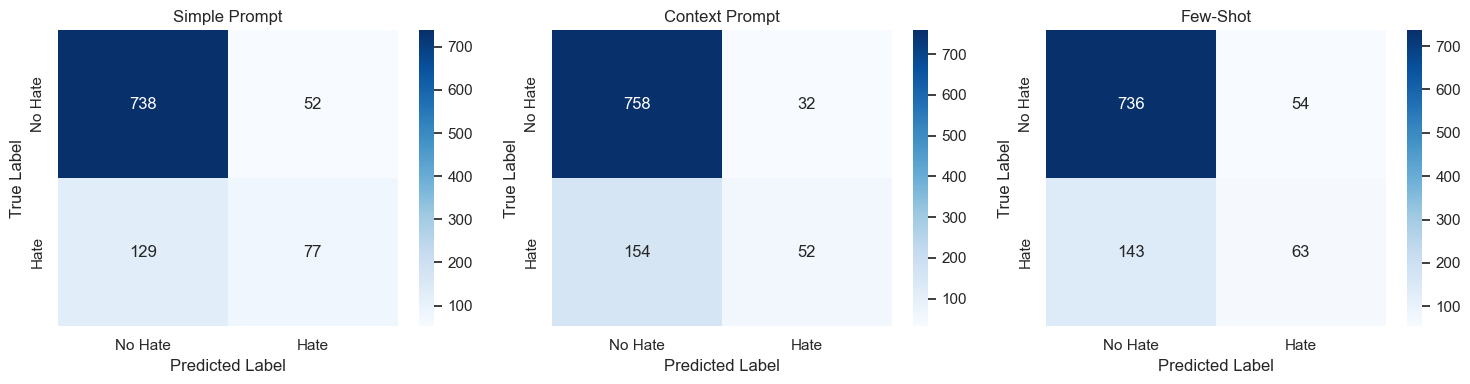

Saved confusion matrices to results/llm_confusion_matrices.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (metrics, title) in enumerate([
    (simple_metrics, "Simple Prompt"),
    (context_metrics, "Context Prompt"),
    (fewshot_metrics, "Few-Shot")
]):
    cm = metrics["Confusion Matrix"]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx],
                xticklabels=["No Hate", "Hate"],
                yticklabels=["No Hate", "Hate"])
    axes[idx].set_title(title)
    axes[idx].set_ylabel("True Label")
    axes[idx].set_xlabel("Predicted Label")

plt.tight_layout()
plt.savefig("results/llm_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved confusion matrices to results/llm_confusion_matrices.png")

### Comparison with Existing Baselines

Load existing model results and compare LLM zero-shot performance against KNN, ensemble, and baseline models.

In [10]:
# Try to load existing results (placeholder path)
baseline_results = None
try:
    if os.path.exists(RESULTS_CSV):
        baseline_results = pd.read_csv(RESULTS_CSV)
        print(f"Loaded baseline results from {RESULTS_CSV}")
        print(baseline_results.head())
    else:
        print(f"Results CSV not found at {RESULTS_CSV}")
        print("Will create synthetic comparison dataframe for now")
except Exception as e:
    print(f"Could not load baseline results: {e}")

Results CSV not found at results/results_PLACEHOLDER.csv
Will create synthetic comparison dataframe for now


In [11]:
# Build comparison dataframe
# If baseline results exist, merge with LLM results
comparison_data = [
    {"Model": "Gemma 3 (Simple)", "F1": simple_metrics["F1"], "Accuracy": simple_metrics["Accuracy"]},
    {"Model": "Gemma 3 (Context)", "F1": context_metrics["F1"], "Accuracy": context_metrics["Accuracy"]},
    {"Model": "Gemma 3 (Few-Shot)", "F1": fewshot_metrics["F1"], "Accuracy": fewshot_metrics["Accuracy"]},
]

# If baseline results exist, add best KNN, ensemble, baseline models
if baseline_results is not None:
    # filter for best models (adjust column names as needed)
    try:
        # This is a placeholder; adjust to match your actual CSV structure
        if "model_type" in baseline_results.columns:
            knn_best = baseline_results[baseline_results["model_type"] == "knn"].sort_values("f1", ascending=False).iloc[0]
            ensemble_best = baseline_results[baseline_results["model_type"] == "ensemble"].sort_values("f1", ascending=False).iloc[0]
            baseline_best = baseline_results[baseline_results["model_type"] == "baseline"].sort_values("f1", ascending=False).iloc[0]
            
            comparison_data.extend([
                {"Model": "Best KNN", "F1": knn_best["f1"], "Accuracy": knn_best["accuracy"]},
                {"Model": "Best Ensemble", "F1": ensemble_best["f1"], "Accuracy": ensemble_best["accuracy"]},
                {"Model": "Baseline", "F1": baseline_best["f1"], "Accuracy": baseline_best["accuracy"]},
            ])
    except Exception as e:
        print(f"Could not extract baseline models: {e}")
else:
    # Add placeholder baselines for visualization
    comparison_data.extend([
        {"Model": "Best KNN (placeholder)", "F1": 0.72, "Accuracy": 0.75},
        {"Model": "Best Ensemble (placeholder)", "F1": 0.78, "Accuracy": 0.80},
        {"Model": "Baseline (placeholder)", "F1": 0.65, "Accuracy": 0.68},
    ])

comparison_df = pd.DataFrame(comparison_data)
print("\n=== Model Comparison ===")
print(comparison_df.to_string(index=False))


=== Model Comparison ===
                      Model       F1  Accuracy
           Gemma 3 (Simple) 0.459701  0.818273
          Gemma 3 (Context) 0.358621  0.813253
         Gemma 3 (Few-Shot) 0.390093  0.802209
     Best KNN (placeholder) 0.720000  0.750000
Best Ensemble (placeholder) 0.780000  0.800000
     Baseline (placeholder) 0.650000  0.680000


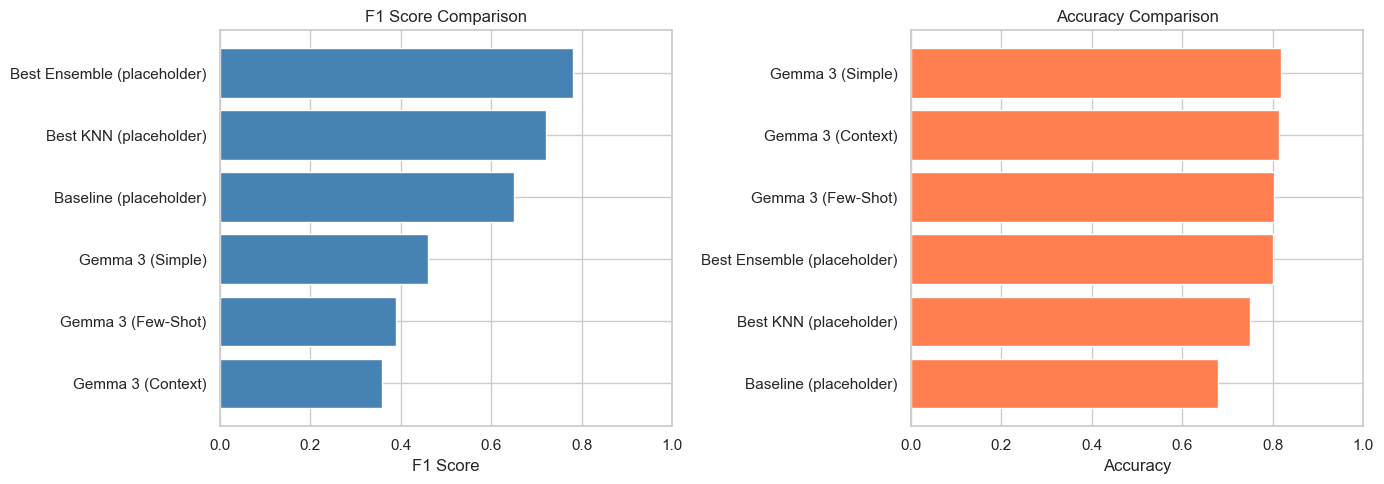

Saved comparison plot to results/llm_vs_baselines.png


In [12]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 comparison
comparison_df_sorted = comparison_df.sort_values("F1", ascending=True)
axes[0].barh(comparison_df_sorted["Model"], comparison_df_sorted["F1"], color="steelblue")
axes[0].set_xlabel("F1 Score")
axes[0].set_title("F1 Score Comparison")
axes[0].set_xlim(0, 1)

# Accuracy comparison
comparison_df_sorted = comparison_df.sort_values("Accuracy", ascending=True)
axes[1].barh(comparison_df_sorted["Model"], comparison_df_sorted["Accuracy"], color="coral")
axes[1].set_xlabel("Accuracy")
axes[1].set_title("Accuracy Comparison")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig("results/llm_vs_baselines.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved comparison plot to results/llm_vs_baselines.png")

### Save Results

In [13]:
# Save detailed results
results_df.to_csv("results/llm_zero_shot_variants.csv", index=False)

# Save full predictions for further analysis
predictions_df = pd.DataFrame({
    "text": texts,
    "gold_label": labels,
    "simple_pred": simple_predictions,
    "context_pred": context_predictions,
    "fewshot_pred": fewshot_predictions,
    "simple_raw": simple_raw_responses,
    "context_raw": context_raw_responses,
    "fewshot_raw": fewshot_raw_responses
})
predictions_df.to_csv("results/llm_predictions_detailed.csv", index=False)

print("Saved results to:")
print("  - results/llm_zero_shot_variants.csv")
print("  - results/llm_predictions_detailed.csv")
print("  - results/llm_confusion_matrices.png")
print("  - results/llm_vs_baselines.png")

Saved results to:
  - results/llm_zero_shot_variants.csv
  - results/llm_predictions_detailed.csv
  - results/llm_confusion_matrices.png
  - results/llm_vs_baselines.png


## Section 2: Gemma 4 Fine-tuned with Density-Ratio Weighting (Unsloth)

Fine-tune Gemma 4 E4B using Unsloth with LoRA adapters. Training data is density-weighted using the density ratio from KNN analysis, following the same approach as `knn_modernbert_trainer_refactored.ipynb`.

### Load Gemma 4 Model with Unsloth + LoRA

In [3]:
import os
import pandas as pd
import numpy as np
import torch
from datasets import Dataset, DatasetDict
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_recall_fscore_support, confusion_matrix, balanced_accuracy_score
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    Trainer, 
    TrainingArguments, 
    EvalPrediction,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)
from transformers import pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass, field
from typing import Any, Dict, List, Union, Optional
import warnings
import dataHandler as dh # Ensure dataHandler.py is in the same directory

# CheckList Imports
try:
    from checklist.pred_wrapper import PredictorWrapper
    from checklist.test_types import MFT
except ImportError:
    print("CheckList library not found. Please install it using `pip install checklist`.")

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

W0408 19:43:09.519000 23200 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [4]:
def setup_device():
    """Checks compute device availability and sets up the device."""
    print("="*60)
    print("CHECKING COMPUTE DEVICE STATUS")
    print("="*60)
    
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"✓ CUDA available: True")
        print(f"✓ CUDA device count: {torch.cuda.device_count()}")
        print(f"✓ Current device: {torch.cuda.current_device()}")
        print(f"✓ Device name: {torch.cuda.get_device_name(0)}")
        try:
            torch.cuda.empty_cache()
            print(f"✓ CUDA cache cleared successfully")
        except Exception as e:
            print(f"⚠ Warning clearing CUDA cache: {e}")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
         device = torch.device("mps")
         print("✓ MPS (Apple Silicon) available: True")
    else:
        device = torch.device("cpu")
        print("✓ CUDA not available, using CPU")
        
    return device

device = setup_device()
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

CHECKING COMPUTE DEVICE STATUS
✓ CUDA not available, using CPU


In [16]:
from unsloth import FastModel
import torch

# Load Gemma 4 E4B with 4-bit quantization
ft_model, ft_tokenizer = FastModel.from_pretrained(
    model_name="unsloth/gemma-4-E2B-it",
    max_seq_length=512,
    load_in_4bit=True,
    full_finetuning=False,
)

# Add LoRA adapters
ft_model = FastModel.get_peft_model(
    ft_model,
    finetune_vision_layers=False,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    r=8,
    lora_alpha=8,
    lora_dropout=0,
    bias="none",
    random_state=3407,
)

# Apply Gemma 4 chat template (non-thinking for classification)
from unsloth.chat_templates import get_chat_template
ft_tokenizer = get_chat_template(
    ft_tokenizer,
    chat_template="gemma-4",
)

print("Gemma 4 E4B loaded with LoRA adapters")

==((====))==  Unsloth 2026.4.4: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 4070. Num GPUs = 1. Max memory: 11.994 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


HfHubHTTPError: Server error '500 Internal Server Error' for url 'https://huggingface.co/api/resolve-cache/models/unslothai/1/7ec782b7604cd9ea0781c23a4270f031650f5617/README.md' (Request ID: Root=1-69d6efba-77d745d55b77474d434a8c06;8932b7bd-ca9c-4e3d-8371-fa4ac8ab6497)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/500

Internal Error - We're working hard to fix this as soon as possible!

### Prepare Density-Weighted Training Data

In [ ]:
# Load KNN training data with density ratios
df_train = pd.read_csv('select_knn_complete_2/samplex_knnratio_k100.csv')
print(f"Loaded {len(df_train)} training samples")

# Density-weighted sampling (same approach as knn_modernbert_trainer_refactored)
weights = df_train['density_ratio'].values.copy()
weights = np.clip(weights, 0, None)
weights = weights / weights.sum()

TRAIN_SIZE = 5000  # Capped for initial testing
df_sampled = df_train.sample(
    n=TRAIN_SIZE, weights=weights, replace=True, random_state=42
).reset_index(drop=True)
print(f"Resampled to {len(df_sampled)} density-weighted samples")

CLASSIFY_PROMPT = "Classify the following text as 'hate' or 'no hate'. Only respond with the label."

def format_sample(row):
    lbl = "hate" if row['label'] == 1 or row['label'] == 'hate' else "no hate"
    txt = CLASSIFY_PROMPT + "\n\nText: " + str(row['text']) + "\n\nLabel:"
    return [
        {"role": "user", "content": [{"type": "text", "text": txt}]},
        {"role": "assistant", "content": [{"type": "text", "text": lbl}]}
    ]

conversations = [format_sample(r) for _, r in df_sampled.iterrows()]

def fmt_func(examples):
    texts = [ft_tokenizer.apply_chat_template(
        c, tokenize=False, add_generation_prompt=False
    ).removeprefix('<bos>') for c in examples["conversations"]]
    return {"text": texts}

from datasets import Dataset as HFDataset
ft_dataset = HFDataset.from_dict({"conversations": conversations})
ft_dataset = ft_dataset.map(fmt_func, batched=True)
print(f"Dataset ready: {len(ft_dataset)} samples")

### Train and Save Model

In [ ]:
from trl import SFTTrainer, SFTConfig
from unsloth.chat_templates import train_on_responses_only

FT_MODEL_DIR = "models_gemma4_finetuned/final"

ft_trainer = SFTTrainer(
    model=ft_model,
    tokenizer=ft_tokenizer,
    train_dataset=ft_dataset,
    eval_dataset=None,
    args=SFTConfig(
        dataset_text_field="text",
        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,
        warmup_steps=5,
        max_steps=200,  # Capped for testing
        learning_rate=2e-4,
        logging_steps=10,
        optim="adamw_8bit",
        weight_decay=0.001,
        lr_scheduler_type="linear",
        seed=3407,
        output_dir="models_gemma4_finetuned",
        report_to="none",
    ),
)

# Train only on model responses (ignore user prompt loss)
ft_trainer = train_on_responses_only(
    ft_trainer,
    instruction_part="<|turn>user\n",
    response_part="<|turn>model\n",
)

print("Starting Gemma 4 fine-tuning with density-weighted data...")
trainer_stats = ft_trainer.train()

# Save model locally
ft_model.save_pretrained(FT_MODEL_DIR)
ft_tokenizer.save_pretrained(FT_MODEL_DIR)
print(f"Model saved to {FT_MODEL_DIR}")
print(f"Training complete! Final loss: {trainer_stats.training_loss:.4f}")

### Evaluate Fine-tuned Model on Russian Test Set

In [ ]:
# Enable inference mode
FastModel.for_inference(ft_model)

print(f"Running inference on {len(texts)} Russian test samples...")
ft_predictions = []
ft_raw_responses = []

for text_sample in tqdm(texts):
    messages = [{"role": "user", "content": [{"type": "text", "text": CLASSIFY_PROMPT + "\n\nText: " + text_sample + "\n\nLabel:"}]}]
    inputs = ft_tokenizer.apply_chat_template(
        messages, add_generation_prompt=True,
        tokenize=True, return_dict=True, return_tensors="pt",
    ).to("cuda")
    with torch.no_grad():
        output_ids = ft_model.generate(
            **inputs, max_new_tokens=16, use_cache=True, temperature=0.01,
        )
    response = ft_tokenizer.decode(
        output_ids[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True
    ).strip()
    ft_raw_responses.append(response)
    ft_predictions.append(parse_response(response))

print(f"Collected {len(ft_predictions)} predictions")

### Results & Comparison

In [ ]:
# Compute metrics for fine-tuned model
ft_metrics = compute_metrics(ft_predictions, labels, "Gemma 4 FT")

print("\n=== Fine-tuned Gemma 4 (Density-Weighted) Results ===")
for k, v in ft_metrics.items():
    if k not in ["Prompt", "Confusion Matrix"]:
        print(f"  {k}: {v:.6f}")

# Confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
cm = ft_metrics["Confusion Matrix"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["No Hate", "Hate"], yticklabels=["No Hate", "Hate"])
ax.set_title("Gemma 4 FT (Density-Weighted)")
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("results/llm_gemma4_ft_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Updated comparison table
ft_row = {
    "Variant": "Gemma 4 FT (Density)",
    "Accuracy": ft_metrics["Accuracy"],
    "Balanced Accuracy": ft_metrics["Balanced Accuracy"],
    "F1": ft_metrics["F1"],
    "AUC-ROC": ft_metrics["AUC-ROC"],
    "Precision": ft_metrics["Precision"],
    "Recall": ft_metrics["Recall"]
}
all_results = pd.concat([results_df, pd.DataFrame([ft_row])], ignore_index=True)
print("\n=== All LLM Results ===")
print(all_results.to_string(index=False))
all_results.to_csv("results/llm_all_variants_with_ft.csv", index=False)
print("Saved to results/llm_all_variants_with_ft.csv")